# SMS Spam Classifier

**NLP task:** Text classification. Every SMS message gets exactly one label: `spam` or `ham` (a normal message).

**Dataset:** [SMS Spam Collection](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset) (Kaggle / UCI), 5,572 real English SMS messages, each labeled by hand.

**Pipeline:**
1. Load and explore the data
2. Clean the text (lowercase, replace links/numbers, remove punctuation and stopwords, stemming)
3. Turn text into numbers with TF-IDF
4. Train and compare three models
5. Evaluate the best model on messages it has never seen
6. Look inside the model: which words signal spam, and where does it make mistakes?

## 1. Load the data

The file uses `latin-1` encoding (not the default UTF-8) because some messages contain special characters like `£`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


`v1` is the label, `v2` is the message. The `Unnamed` columns are almost empty (a formatting quirk of the file), so we drop them.

In [2]:
# Cell 2: keep only the label and message columns, with clear names
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Explore the data

Before building anything, we check: how many messages, how balanced the labels are, whether there are duplicates, and whether spam looks different from ham.

In [3]:
# Cell 3: explore the data
print("Shape:", df.shape)
print("\nLabel counts:\n", df['label'].value_counts())
print("\nLabel percentages:\n", df['label'].value_counts(normalize=True) * 100)
print("\nDuplicate messages:", df.duplicated().sum())

df['length'] = df['message'].str.len()
print("\nAverage length by label:\n", df.groupby('label')['length'].mean())

Shape: (5572, 2)

Label counts:
 label
ham     4825
spam     747
Name: count, dtype: int64

Label percentages:
 label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

Duplicate messages: 403

Average length by label:
 label
ham      71.023627
spam    138.866131
Name: length, dtype: float64


**What we learn:**
- Only ~13% of messages are spam, so the classes are **imbalanced**. A model that always says "ham" would be 87% accurate while catching zero spam, so accuracy alone is misleading. We will focus on **precision, recall and F1** for the spam class.
- There are **403 duplicates** (often the same spam sent to many people). If we kept them, the same message could land in both training and test data and make the score look better than it really is. We remove them.

In [4]:
# Cell 4: remove duplicate messages
df = df.drop_duplicates(subset='message').reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)
print(df['label'].value_counts())

Shape after removing duplicates: (5169, 3)
label
ham     4516
spam     653
Name: count, dtype: int64


Spam messages are about twice as long as ham on average. The chart compares the *shape* of each class (`density=True`), so the smaller spam class is still visible.

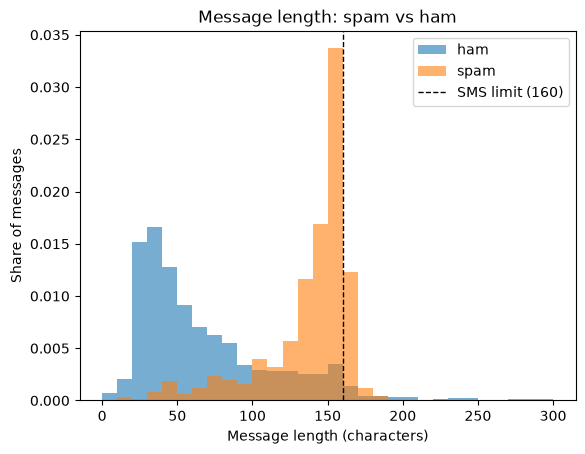

In [5]:
# Cell 5: compare message length by label
bins = range(0, 301, 10)   # same bins for both, 0 to 300 characters

df[df['label'] == 'ham']['length'].plot.hist(bins=bins, alpha=0.6, density=True, label='ham')
df[df['label'] == 'spam']['length'].plot.hist(bins=bins, alpha=0.6, density=True, label='spam')
plt.axvline(160, color='black', linestyle='--', linewidth=1, label='SMS limit (160)')
plt.xlabel('Message length (characters)')
plt.ylabel('Share of messages')
plt.title('Message length: spam vs ham')
plt.legend()
plt.savefig('../reports/length_chart.png', bbox_inches='tight')
plt.show()

Ham is mostly short ("Ok lar...", "On my way"). Spam is packed right up to the **160-character limit** of a single SMS: spammers use all the space they get.

## 3. Clean the text

A model counts words, so the same word should always look the same. Each step has a reason:

| Step | Example | Why |
|---|---|---|
| Lowercase | "FREE" → "free" | "FREE", "Free" and "free" count as one word |
| Replace links | "www.win.com" → "url" | Every link is different, but *having* a link is a spam clue |
| Replace numbers | "£1000", "08712460324" → "num" | Every number is different, but *having* numbers is a spam clue |
| Remove punctuation | "lar..." → "lar" | Dots and commas add noise |
| Remove stopwords | drop "the", "is", "and" | They appear everywhere, so they don't separate spam from ham |
| Stemming | "winning", "wins" → "win" | Groups forms of the same word together |

In [6]:
# Cell 6: set up NLTK tools
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

In [7]:
# Cell 7: the cleaning function
def clean_text(text):
    text = text.lower()                                    # 1. lowercase
    text = re.sub(r'http\S+|www\.\S+', ' url ', text)      # 2. links -> "url"
    text = re.sub(r'\d+', ' num ', text)                   # 3. numbers -> "num"
    text = re.sub(r'[^a-z\s]', ' ', text)                  # 4. keep only letters and spaces
    words = text.split()                                   # split into words
    words = [w for w in words if w not in stop_words]      # 5. remove stopwords
    words = [stemmer.stem(w) for w in words]               # 6. stemming
    return ' '.join(words)

# Test it on one spam and one ham message before using it on everything
for i in [2, 1]:
    print(df['label'][i].upper())
    print("  BEFORE:", df['message'][i])
    print("  AFTER: ", clean_text(df['message'][i]))
    print()

SPAM
  BEFORE: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  AFTER:  free entri num wkli comp win fa cup final tkt num st may num text fa num receiv entri question std txt rate c appli num num

HAM
  BEFORE: Ok lar... Joking wif u oni...
  AFTER:  ok lar joke wif u oni



Stemmed words can look cut off ("entri", "wkli"). That's expected: the stemmer doesn't produce real words, it only makes sure different forms of a word end up identical.

In [8]:
# Cell 8: clean every message
df['clean_message'] = df['message'].apply(clean_text)
df[['label', 'message', 'clean_message']].head(10)

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri num wkli comp win fa cup final tkt ...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though
5,spam,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darl num week word back like fun s...
6,ham,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,ham,As per your request 'Melle Melle (Oru Minnamin...,per request mell mell oru minnaminungint nurun...
8,spam,WINNER!! As a valued network customer you have...,winner valu network custom select receivea num...
9,spam,Had your mobile 11 months or more? U R entitle...,mobil num month u r entitl updat latest colour...


## 4. Split into training and test data

We hide 20% of the messages as a **test set**. The model never sees them while learning, so they tell us how well it works on *new* messages.

- `stratify=y` keeps the same spam/ham ratio (~13% spam) in both parts.
- `random_state=42` makes the split the same every time we run the notebook.
- Labels become numbers: `ham = 0`, `spam = 1`.

In [9]:
# Cell 9: train/test split
from sklearn.model_selection import train_test_split

X = df['clean_message']
y = (df['label'] == 'spam').astype(int)   # spam = 1, ham = 0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training messages:", len(X_train), f"({y_train.mean():.1%} spam)")
print("Test messages:    ", len(X_test), f"({y_test.mean():.1%} spam)")

Training messages: 4135 (12.6% spam)
Test messages:     1034 (12.7% spam)


## 5. Turn text into numbers: TF-IDF

Models only understand numbers. **TF-IDF** gives every word a score in every message:

- **TF (term frequency):** how often the word appears in *this* message.
- **IDF (inverse document frequency):** how rare the word is across *all* messages. Rare words get a higher weight, common words a lower one.

So a word scores high when it's frequent in this message but rare overall; that's what makes it informative.

`ngram_range=(1, 2)` also counts **pairs of words** (like "call num" or "free entri"), which carry more meaning than single words. `min_df=2` ignores words that appear in only one message (typos, one-off names).

**Important:** the vectorizer learns its vocabulary from the *training* data only. If it saw the test messages, information would leak and the results would look better than they really are.

In [10]:
# Cell 10: TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
X_train_vec = vectorizer.fit_transform(X_train)   # learn vocabulary + transform
X_test_vec = vectorizer.transform(X_test)         # only transform (no learning)

print("Each message is now a row of", X_train_vec.shape[1], "numbers (one per word or word pair)")
print("Training matrix shape:", X_train_vec.shape)

# Show the TF-IDF scores for one message
example = 0
row = X_train_vec[example]
words = vectorizer.get_feature_names_out()[row.indices]
print("\nMessage:", X_train.iloc[example])
print(pd.Series(row.data, index=words).sort_values(ascending=False).round(3))

Each message is now a row of 5790 numbers (one per word or word pair)
Training matrix shape: (4135, 5790)

Message: cool come havent wine dine
wine dine    0.448
cool come    0.448
dine         0.433
wine         0.383
havent       0.342
cool         0.316
come         0.218
dtype: float64


## 6. Baseline: the "always ham" model

Before training a real model, we check what a useless model scores. This proves why accuracy alone is misleading on imbalanced data.

In [11]:
# Cell 11: baseline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline = DummyClassifier(strategy='most_frequent')   # always predicts the most common label (ham)
baseline.fit(X_train_vec, y_train)
baseline_pred = baseline.predict(X_test_vec)

print(f"Accuracy:     {accuracy_score(y_test, baseline_pred):.1%}")
print(f"Spam recall:  {recall_score(y_test, baseline_pred):.1%}  <- catches no spam at all")

Accuracy:     87.3%
Spam recall:  0.0%  <- catches no spam at all


## 7. Train and compare three models

| Model | Idea in one sentence |
|---|---|
| **Multinomial Naive Bayes** | Learns how likely each word is in spam vs ham, then combines those probabilities. The classic spam filter. |
| **Logistic Regression** | Learns a weight per word (positive = spammy, negative = hammy) and adds them up. |
| **Linear SVM** | Finds the boundary that separates spam from ham with the widest possible margin. |

To choose fairly, we use **5-fold cross-validation on the training data only**: the training set is split into 5 parts, each model trains on 4 and is tested on the 5th, five times. The test set stays untouched until the very end.

Each model is wrapped in a `Pipeline` with its own TF-IDF, so in every fold the vocabulary is learned only from that fold's training part.

In [12]:
# Cell 12: compare models with cross-validation
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate

models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Linear SVM': LinearSVC(class_weight='balanced'),
}

results = []
for name, model in models.items():
    pipe = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=2), model)
    scores = cross_validate(pipe, X_train, y_train, cv=5,
                            scoring=['accuracy', 'precision', 'recall', 'f1'])
    results.append({
        'model': name,
        'accuracy': scores['test_accuracy'].mean(),
        'precision': scores['test_precision'].mean(),
        'recall': scores['test_recall'].mean(),
        'f1': scores['test_f1'].mean(),
    })

results = pd.DataFrame(results).set_index('model').sort_values('f1', ascending=False)
results.round(3)

,accuracy,precision,recall,f1
model,,,,
Linear SVM,0.985,0.946,0.935,0.940
Naive Bayes,0.977,0.998,0.818,0.898
Logistic Regression,0.972,0.859,0.931,0.893


`class_weight='balanced'` tells Logistic Regression and the SVM to pay extra attention to the rarer spam class, so they don't just lean towards "ham".

We pick the model with the best **F1-score**, the balance between precision (don't flag real messages) and recall (catch the spam).

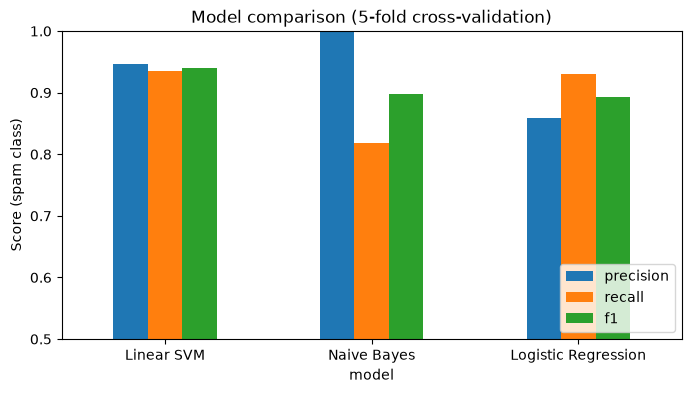

In [13]:
# Cell 13: chart of the comparison
ax = results[['precision', 'recall', 'f1']].plot.bar(rot=0, figsize=(8, 4))
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score (spam class)')
ax.set_title('Model comparison (5-fold cross-validation)')
ax.legend(loc='lower right')
plt.savefig('../reports/model_comparison.png', bbox_inches='tight')
plt.show()

## 8. Final evaluation on the test set

Now we train the best model on all training data and test it **once** on the 20% it has never seen.

In [14]:
# Cell 14: train the best model and evaluate on the test set
from sklearn.metrics import classification_report

best_name = results.index[0]
best_model = models[best_name]
best_model.fit(X_train_vec, y_train)
y_pred = best_model.predict(X_test_vec)

print("Best model:", best_name)
print()
print(classification_report(y_test, y_pred, target_names=['ham', 'spam'], digits=3))

Best model: Linear SVM

              precision    recall  f1-score   support

         ham      0.990     0.990     0.990       903
        spam      0.931     0.931     0.931       131

    accuracy                          0.983      1034
   macro avg      0.961     0.961     0.961      1034
weighted avg      0.983     0.983     0.983      1034



**How to read this:**
- **Precision (spam):** when the model says "spam", how often is it right? Low precision means real messages get thrown away, which is the worst outcome for a user.
- **Recall (spam):** of all the real spam, how much did the model catch?
- **F1:** the balance of the two.

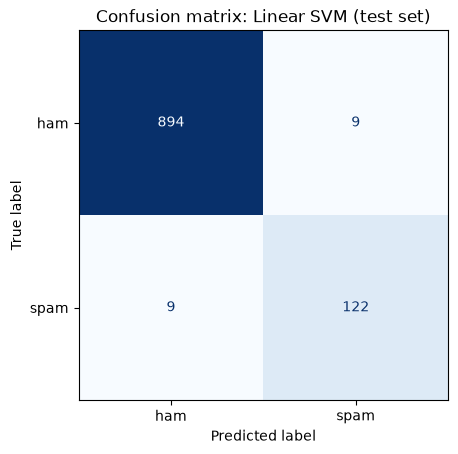

In [15]:
# Cell 15: confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['ham', 'spam'], cmap='Blues', colorbar=False
)
plt.title(f'Confusion matrix: {best_name} (test set)')
plt.savefig('../reports/confusion_matrix.png', bbox_inches='tight')
plt.show()

The confusion matrix shows exact counts:
- **Top-left:** ham correctly kept. **Bottom-right:** spam correctly caught.
- **Top-right:** ham wrongly flagged as spam (false alarms).
- **Bottom-left:** spam that slipped through.

## 9. Look inside the model: which words signal spam?

Logistic Regression gives every word (and word pair) a weight. Positive weights push towards spam, negative towards ham. It's the easiest model to interpret, so we use it here even if another model scored slightly higher.

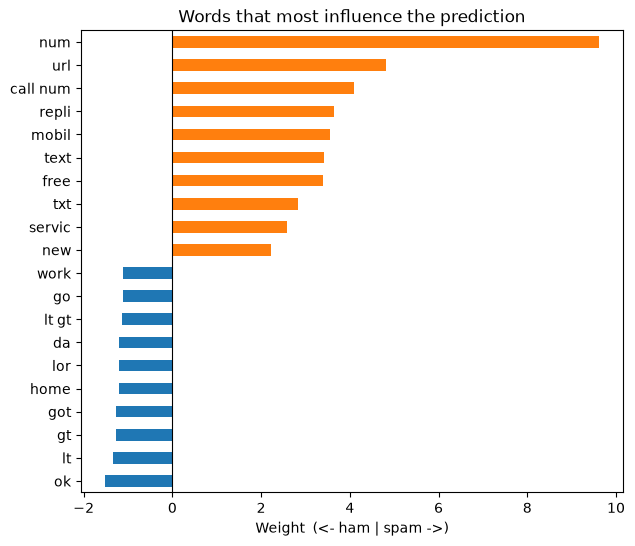

In [16]:
# Cell 16: most spammy and most hammy words
lr = LogisticRegression(class_weight='balanced', max_iter=1000).fit(X_train_vec, y_train)
weights = pd.Series(lr.coef_[0], index=vectorizer.get_feature_names_out())

top = pd.concat([weights.nsmallest(10), weights.nlargest(10)]).sort_values()
colors = ['tab:blue' if w < 0 else 'tab:orange' for w in top]

top.plot.barh(color=colors, figsize=(7, 6))
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Weight  (<- ham | spam ->)')
plt.title('Words that most influence the prediction')
plt.savefig('../reports/top_words.png', bbox_inches='tight')
plt.show()

**What the model learned:**
- **Spam signals:** `num` (numbers: prize amounts, phone numbers, short codes), `url`, `call num`, `repli`, `text`, `free`, `mobil`. Replacing every number with `num` in the cleaning step turned out to create the strongest clue of all.
- **Ham signals:** everyday chat words like `ok`, `home`, `got`, `lor`, `da` (Singlish/Indian English slang common in this dataset).
- `lt` and `gt` come from `&lt;#&gt;`, a placeholder the dataset creators put in *normal* messages to hide personal numbers. So they point towards ham. It's a quirk of this dataset that a model trained on real-world SMS wouldn't see.

## 10. Where does the model make mistakes?

Looking at the errors helps explain the model's limits.

In [17]:
# Cell 17: show the misclassified test messages
test_results = pd.DataFrame({
    'message': df.loc[X_test.index, 'message'],
    'actual': y_test.map({0: 'ham', 1: 'spam'}),
    'predicted': pd.Series(y_pred, index=X_test.index).map({0: 'ham', 1: 'spam'}),
})
mistakes = test_results[test_results['actual'] != test_results['predicted']]

pd.set_option('display.max_colwidth', 200)
print(len(mistakes), "mistakes out of", len(test_results), "test messages")
mistakes

18 mistakes out of 1034 test messages


,message,actual,predicted
1793,K.:)you are the only girl waiting in reception ah?,ham,spam
3947,Missed call alert. These numbers called but left no message. 07008009200,spam,ham
4806,K k:) sms chat with me.,ham,spam
660,SMS. ac sun0819 posts HELLO:\You seem cool,spam,ham
2888,Your bill at 3 is å£33.65 so thats not bad!,ham,spam
2302,Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rude time with a sexy bitch. How about we go slo n hard! Txt XXX SLO(4msgs),spam,ham
3888,"In The Simpsons Movie released in July 2007 name the band that died at the start of the film? A-Green Day, B-Blue Day, C-Red Day. (Send A, B or C)",spam,ham
3330,"Xmas & New Years Eve tickets are now on sale from the club, during the day from 10am till 8pm, and on Thurs, Fri & Sat night this week. They're selling fast!",spam,ham
3586,Yep then is fine 7.30 or 8.30 for ice age.,ham,spam
2269,V nice! Off 2 sheffield tom 2 air my opinions on categories 2 b used 2 measure ethnicity in next census. Busy transcribing. :-),ham,spam


## 11. Try it on new messages

The full pipeline for a brand-new message is: **clean → TF-IDF → model**.

In [18]:
# Cell 18: predict new messages
def predict(message):
    cleaned = clean_text(message)
    vec = vectorizer.transform([cleaned])
    return 'SPAM' if best_model.predict(vec)[0] == 1 else 'ham'

new_messages = [
    "Congratulations! You have won a £500 prize. Call 09061701461 now to claim",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: your account has been selected for a free reward. Text WIN to 80086",
    "Can you pick up some bread on your way home?",
    "Free entry! Win tickets to the final, reply YES to 87121",
]

for m in new_messages:
    print(f"{predict(m):5}  |  {m}")

SPAM   |  Congratulations! You have won a £500 prize. Call 09061701461 now to claim
ham    |  Hey, are we still meeting for lunch tomorrow?
SPAM   |  URGENT: your account has been selected for a free reward. Text WIN to 80086
ham    |  Can you pick up some bread on your way home?
SPAM   |  Free entry! Win tickets to the final, reply YES to 87121


## 12. Summary

| | |
|---|---|
| **Data** | 5,572 SMS messages → 5,169 after removing duplicates (12.6% spam) |
| **Cleaning** | lowercase, links → `url`, numbers → `num`, remove punctuation and stopwords, Porter stemming (NLTK) |
| **Features** | TF-IDF on single words and word pairs, 5,790 features |
| **Model** | Linear SVM (best of 3 by cross-validated F1) |

**Test set results (1,034 unseen messages):**

| Metric | "Always ham" baseline | Linear SVM |
|---|---|---|
| Accuracy | 87.3% | **98.3%** |
| Spam precision | n/a | **93.1%** |
| Spam recall | 0% | **93.1%** |
| Spam F1 | 0 | **0.931** |

- Of 131 spam messages, **122 were caught** and 9 slipped through.
- Of 903 normal messages, **9 were wrongly flagged** as spam.

**Model comparison:** Naive Bayes was almost never wrong when it said "spam" (99.8% precision) but missed about 1 in 5 spam messages (81.8% recall). The Linear SVM gave the best balance.

**Limitations and next steps:**
- The data is English SMS from around 2012 (UK/Singapore). Today's spam (fake delivery texts, mobile money scams) and messages in other languages, like Kinyarwanda, would need new training data.
- Some mistakes are genuinely hard. "Your bill at 3 is £33.65 so thats not bad!" is a normal message, but its numbers make it look like spam. "Missed call alert. These numbers called but left no message." is spam that uses none of the usual spam words.
- Next steps: tune the model settings, try character n-grams (robust to spelling like "fr33"), or fine-tune a transformer model from Hugging Face.